## **Simulation Analysis**

This notebook contains a selection of plots and other analyses of the simulations conducted in run_simulation.py. Please ensure that the simulations are complete before executing this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scripts.plot_osc import *
import os
import pandas as pd
from scripts.bat_class import BatOsc, Ball, bat_from_pkl, ball_from_pkl, ball_from_json, bat_from_json
from scripts.unit_conversions import *

## **Load Results**

In [2]:
sim_key = 'Adley' #unique identifier for the simulation, used to load the correct files
standard_path = f'results/{sim_key}_stan_results.csv'
torp_path = f'results/{sim_key}_torp_results.csv'

standard_df = pd.read_csv(standard_path)
torp_df = pd.read_csv(torp_path)

In [3]:
#load ball params
ball_params_path = f'data/balls/{sim_key}_ball.json'
ball_params = ball_from_json(ball_params_path)
#convert ztip to cm from knob

In [7]:
#Alan results
fname = 'data/bats/AdleyBats.csv'
alan_df = pd.read_csv(fname)
alan_df.rename(columns={'vf/vi-1': 'standard', 'vf/vi-2': 'torp'}, inplace=True)

L = max(standard_df['idx']*1e-2)
alan_df['z'] = L - inches_to_m(alan_df['ztip'].values) 

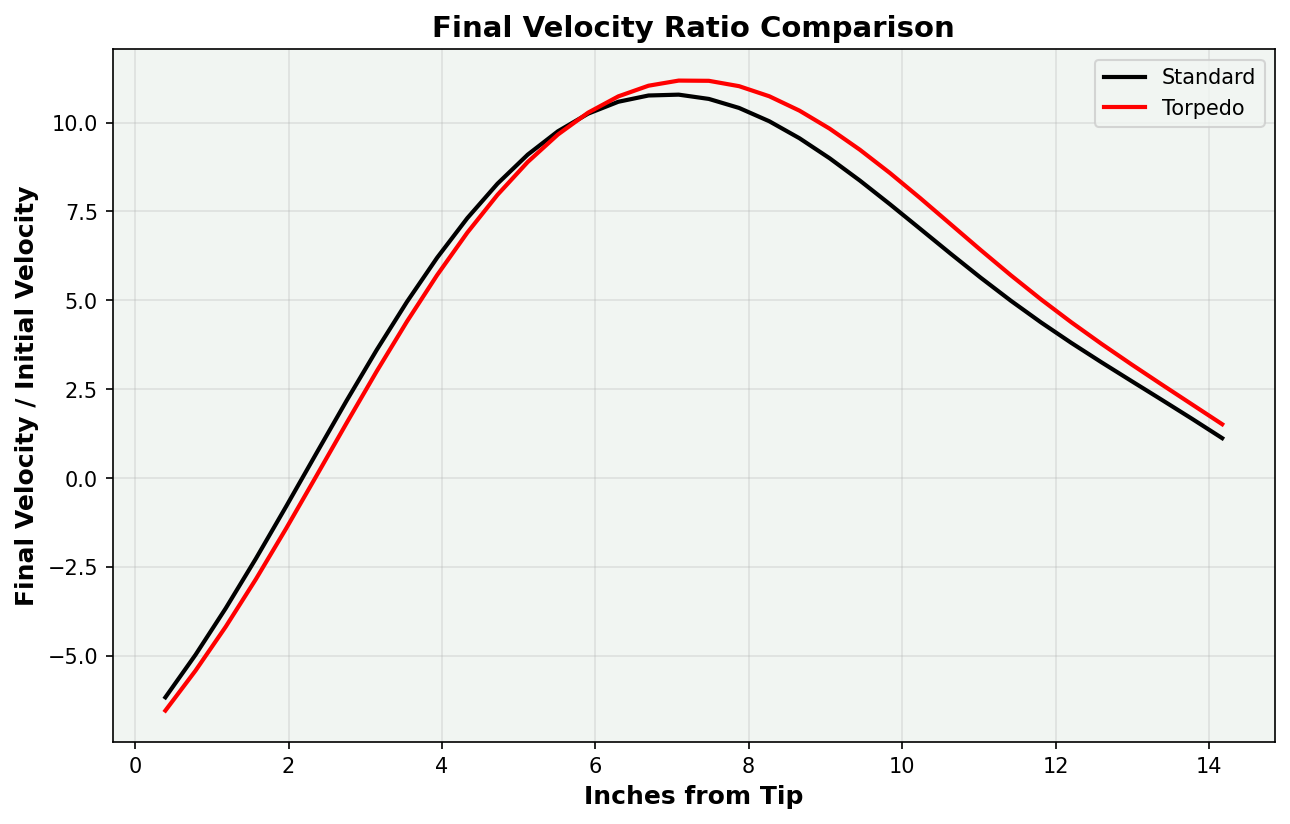

In [10]:
plt.plot(standard_df['ztip'], standard_df['vf'], label='Standard', color = 'k')
plt.plot(torp_df['ztip'], torp_df['vf'], label='Torpedo', color ='r', linestyle = '-')
# plt.plot(alan_df['ztip'], alan_df['standard'], label='Alan Standard', color = 'k', linestyle = '--')
# plt.plot(alan_df['ztip'], alan_df['torp'], label='Alan Torpedo', color = 'r', linestyle = '--')
plt.xlabel('Inches from Tip')
plt.ylabel('Final Velocity / Initial Velocity')
plt.title('Final Velocity Ratio Comparison')
plt.legend()
# plt.ylim(0, 0.27)
plt.savefig('midterm_report/plots/final_velocity_comparison.pdf')
plt.show()

In [15]:
#load bat params
standard_bat = bat_from_json(f'data/bats/AdleyOld.json')
torpedo_bat = bat_from_json(f'data/bats/AdleyNewMod2.json')

#load ball params
ball = ball_from_json(f'data/balls/{sim_key}_ball.json')

In [22]:
#rigid expectation - standard bat
slice_vols = standard_bat.dz * np.pi * (standard_bat.radii)**2 # volume of each slice based on its geometry
slice_masses = standard_bat.dz * standard_bat.rho * np.pi * (standard_bat.radii)**2 # mass of each slice based on its volume and density
M = np.sum(slice_masses) # total mass of the bat by summing the masses of all slices

z = standard_bat.zs[standard_df['idx']] # z coordinate of the impact location

#center of mass and moment of inertia calculations
zcm = np.sum(slice_masses * standard_bat.zs) / M
Icm = np.sum(0.25*slice_masses * (standard_bat.radii)**2 + slice_masses * (standard_bat.zs - zcm)**2) 

#EQ 8 FROM PAPER
inv_Meff = 1/M + (z - zcm) ** 2 / Icm
Meff = 1 / inv_Meff
r_standard = ball.mass / Meff #bat recoil factor

#expected velo
standard_df['e_COR'] = standard_df['vf_vi'] * (1 + r_standard) + r_standard

In [23]:
#rigid expectation - torpedo
slice_vols = torpedo_bat.dz * np.pi * (torpedo_bat.radii)**2 # volume of each slice based on its geometry
slice_masses = torpedo_bat.dz * torpedo_bat.rho * np.pi * (torpedo_bat.radii)**2 # mass of each slice based on its volume and density
M = np.sum(slice_masses) # total mass of the bat by summing the masses of all slices

z = torpedo_bat.zs[torp_df['idx']] # z coordinate of the impact location
zcm = np.sum(slice_masses * torpedo_bat.zs) / M
Icm = np.sum(0.25*slice_masses * (torpedo_bat.radii)**2 + slice_masses * (torpedo_bat.zs - zcm)**2) 

#EQ 8 FROM PAPER
inv_Meff = 1/M + (z - zcm) ** 2 / Icm
Meff = 1 / inv_Meff
r_torp = ball.mass / Meff #bat recoil factor
#expected velo
torp_df['e_COR'] = torp_df['vf_vi'] * (1 + r_torp) + r_torp

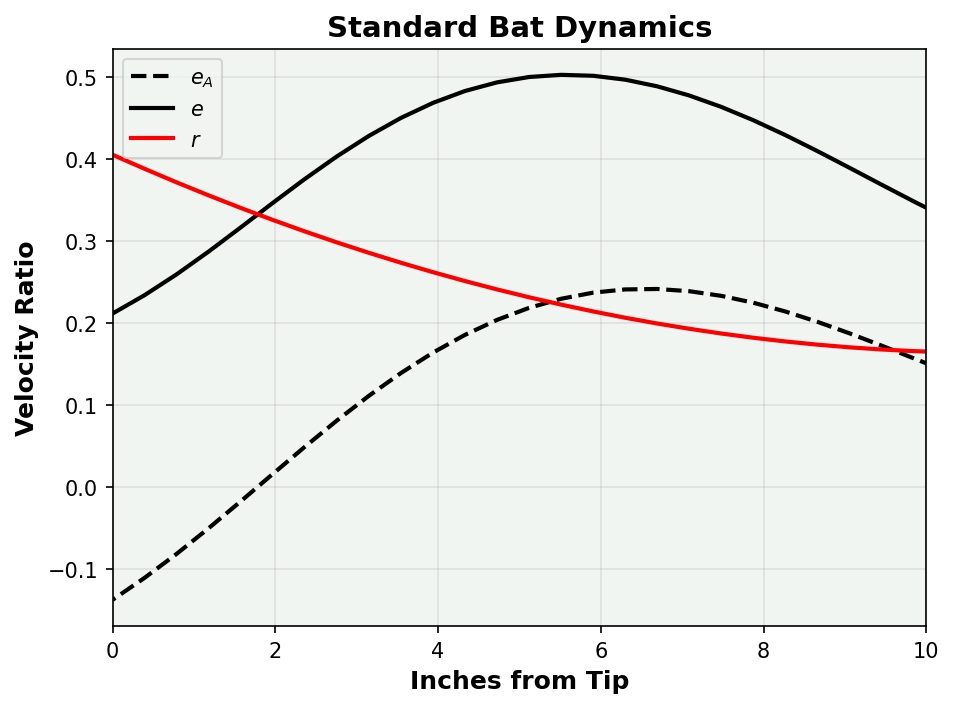

In [30]:
## Recreating Fig 2 from Nathan 2002
plt.figure(figsize=(7,5))
plt.plot(standard_df['ztip'], standard_df['vf_vi'], label='$e_A$', color = 'k', linestyle = '--')
plt.plot(standard_df['ztip'], standard_df['e_COR'], label='$e$', color = 'k', )
plt.plot(standard_df['ztip'], r_standard, color = 'r', label='$r$')
plt.xlabel('Inches from Tip')
plt.ylabel('Velocity Ratio')
plt.title('Standard Bat Dynamics')
plt.legend()
plt.xlim(0, 10)
plt.savefig('plots/standard_bat_dynamics.pdf')